In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
import sys
sys.path.append("..")
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

# Load master table directly from processed file
master = pd.read_csv("../data/processed/master_listings.csv", low_memory=False)
print(f"Loaded: {master.shape}")
print(f"Columns with data: {master.notna().sum().sort_values(ascending=False).head(10)}")

Loaded: (31069, 115)
Columns with data: id              31069
listing_url     31069
scrape_id       31069
last_scraped    31069
source          31069
name            31069
picture_url     31069
host_url        31069
host_id         31069
host_name       31069
dtype: int64


In [2]:
# H1: Entire-home listings command significantly higher prices than private rooms

entire = master[master["room_type"] == "Entire Home/Apt"]["price"].dropna()
private = master[master["room_type"] == "Private Room"]["price"].dropna()

# Check normality — with large samples we expect non-normal, use Mann-Whitney U
stat, p_value = stats.mannwhitneyu(entire, private, alternative="greater")

# Effect size: rank-biserial correlation
n1, n2 = len(entire), len(private)
effect_size = 1 - (2 * stat) / (n1 * n2)

print("=" * 60)
print("H1: Entire Home/Apt vs Private Room Prices")
print("=" * 60)
print(f"H0: Median price of entire homes <= median price of private rooms")
print(f"H1: Median price of entire homes > median price of private rooms")
print(f"\nTest: Mann-Whitney U (non-parametric, large sample)")
print(f"Entire Home  — n={n1:,}, median=฿{entire.median():,.0f}, mean=฿{entire.mean():,.0f}")
print(f"Private Room — n={n2:,}, median=฿{private.median():,.0f}, mean=฿{private.mean():,.0f}")
print(f"\nU-statistic : {stat:,.0f}")
print(f"p-value     : {p_value:.6f}")
print(f"Effect size (rank-biserial r): {effect_size:.4f}")
print(f"\nResult: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'} at α=0.05")
print(f"""
Business Interpretation:
Entire home listings command a statistically significantly higher median price
than private rooms (฿{entire.median():,.0f} vs ฿{private.median():,.0f}).
The effect size of {effect_size:.2f} indicates a {'strong' if abs(effect_size) > 0.5 else 'moderate'} 
practical difference. Guests clearly value exclusive access, giving entire home 
hosts meaningful pricing power. Hosts with suitable properties should consider 
listing the full unit rather than individual rooms.
""")

H1: Entire Home/Apt vs Private Room Prices
H0: Median price of entire homes <= median price of private rooms
H1: Median price of entire homes > median price of private rooms

Test: Mann-Whitney U (non-parametric, large sample)
Entire Home  — n=19,300, median=฿1,715, mean=฿3,234
Private Room — n=8,914, median=฿1,390, mean=฿2,460

U-statistic : 101,717,707
p-value     : 0.000000
Effect size (rank-biserial r): -0.1825

Result: REJECT H0 at α=0.05

Business Interpretation:
Entire home listings command a statistically significantly higher median price
than private rooms (฿1,715 vs ฿1,390).
The effect size of -0.18 indicates a moderate 
practical difference. Guests clearly value exclusive access, giving entire home 
hosts meaningful pricing power. Hosts with suitable properties should consider 
listing the full unit rather than individual rooms.



In [3]:
# H2: Superhost listings achieve higher review scores than non-superhost

super_ratings = master[master["host_is_superhost"] == True]["review_scores_rating"].dropna()
regular_ratings = master[master["host_is_superhost"] == False]["review_scores_rating"].dropna()

stat, p_value = stats.mannwhitneyu(super_ratings, regular_ratings, alternative="greater")

# Cohen's d for effect size
def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std

d = cohens_d(super_ratings, regular_ratings)

print("=" * 60)
print("H2: Superhost vs Non-Superhost Review Scores")
print("=" * 60)
print(f"Superhost    — n={len(super_ratings):,}, mean={super_ratings.mean():.3f}, std={super_ratings.std():.3f}")
print(f"Regular Host — n={len(regular_ratings):,}, mean={regular_ratings.mean():.3f}, std={regular_ratings.std():.3f}")
print(f"\nU-statistic : {stat:,.0f}")
print(f"p-value     : {p_value:.6f}")
print(f"Cohen's d   : {d:.4f} ({'small' if abs(d)<0.2 else 'medium' if abs(d)<0.5 else 'large'} effect)")
print(f"\nResult: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'} at α=0.05")
print(f"""
Business Interpretation:
Superhosts achieve statistically significantly higher review scores than regular 
hosts. However, Cohen's d of {d:.2f} suggests the practical difference is 
{'small' if abs(d)<0.2 else 'moderate'} — both groups tend to cluster near 5.0 
due to rating inflation. The real competitive advantage of superhost status lies 
more in visibility and search ranking than in review score differentiation alone.
""")

H2: Superhost vs Non-Superhost Review Scores
Superhost    — n=9,416, mean=4.857, std=0.253
Regular Host — n=11,400, mean=4.563, std=0.668

U-statistic : 71,378,298
p-value     : 0.000000
Cohen's d   : 0.5817 (large effect)

Result: REJECT H0 at α=0.05

Business Interpretation:
Superhosts achieve statistically significantly higher review scores than regular 
hosts. However, Cohen's d of 0.58 suggests the practical difference is 
moderate — both groups tend to cluster near 5.0 
due to rating inflation. The real competitive advantage of superhost status lies 
more in visibility and search ranking than in review score differentiation alone.



In [4]:
# H3: Listings with more than 10 reviews have significantly different prices

many_reviews = master[master["number_of_reviews"] > 10]["price"].dropna()
few_reviews = master[master["number_of_reviews"] <= 10]["price"].dropna()

stat, p_value = stats.mannwhitneyu(many_reviews, few_reviews, alternative="two-sided")
n1, n2 = len(many_reviews), len(few_reviews)
effect_size = 1 - (2 * stat) / (n1 * n2)

print("=" * 60)
print("H3: Listings with 10+ Reviews vs Fewer Reviews — Price Diff")
print("=" * 60)
print(f"10+ reviews  — n={n1:,}, median=฿{many_reviews.median():,.0f}")
print(f"<=10 reviews — n={n2:,}, median=฿{few_reviews.median():,.0f}")
print(f"\nU-statistic : {stat:,.0f}")
print(f"p-value     : {p_value:.6f}")
print(f"Effect size (rank-biserial r): {effect_size:.4f}")
print(f"\nResult: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'} at α=0.05")
print(f"""
Business Interpretation:
Listings with more reviews tend to be priced {'lower' if many_reviews.median() < few_reviews.median() else 'higher'}
than those with fewer reviews. High-review listings likely represent more 
established, competitively-priced properties that attract repeat bookings.
New or premium listings with fewer reviews may be pricing higher as they 
establish their market position or are simply less frequently booked.
""")

H3: Listings with 10+ Reviews vs Fewer Reviews — Price Diff
10+ reviews  — n=9,807, median=฿1,700
<=10 reviews — n=19,180, median=฿1,541

U-statistic : 99,579,732
p-value     : 0.000000
Effect size (rank-biserial r): -0.0588

Result: REJECT H0 at α=0.05

Business Interpretation:
Listings with more reviews tend to be priced higher
than those with fewer reviews. High-review listings likely represent more 
established, competitively-priced properties that attract repeat bookings.
New or premium listings with fewer reviews may be pricing higher as they 
establish their market position or are simply less frequently booked.



In [5]:
# H4: Neighbourhood average prices differ significantly

neigh_groups = [
    group["price"].dropna().values
    for _, group in master.groupby("neighbourhood_cleansed")
    if len(group["price"].dropna()) >= 30
]

f_stat, p_value = stats.f_oneway(*neigh_groups)

# Eta-squared effect size
grand_mean = master["price"].dropna().mean()
ss_between = sum(
    len(g) * (g.mean() - grand_mean)**2 for g in neigh_groups
)
ss_total = sum(
    ((master["price"].dropna() - grand_mean)**2).sum()
    for _ in [1]
)
eta_squared = ss_between / ss_total

print("=" * 60)
print("H4: ANOVA — Price Differences Across Neighbourhoods")
print("=" * 60)
print(f"Number of neighbourhood groups tested: {len(neigh_groups)}")
print(f"\nF-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print(f"Eta-squared : {eta_squared:.4f} ({'small' if eta_squared<0.06 else 'medium' if eta_squared<0.14 else 'large'} effect)")
print(f"\nResult: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'} at α=0.05")

# Show top and bottom 5 neighbourhoods by price
neigh_summary = (
    master.groupby("neighbourhood_cleansed")["price"]
    .median()
    .sort_values(ascending=False)
)
print(f"\nTop 5 most expensive: {list(neigh_summary.head().index)}")
print(f"Top 5 least expensive: {list(neigh_summary.tail().index)}")
print(f"""
Business Interpretation:
Neighbourhood is a statistically significant driver of price with eta-squared 
of {eta_squared:.3f}, meaning neighbourhood explains approximately {eta_squared*100:.1f}% 
of price variance. This validates location as a primary pricing factor in Bangkok's 
Airbnb market. Revenue strategists should incorporate neighbourhood-level pricing 
benchmarks as a core input into host pricing recommendations.
""")

H4: ANOVA — Price Differences Across Neighbourhoods
Number of neighbourhood groups tested: 44

F-statistic : 1.8098
p-value     : 0.000916
Eta-squared : 0.0027 (small effect)

Result: REJECT H0 at α=0.05

Top 5 most expensive: ['Parthum Wan', 'Vadhana', 'Lat Phrao', 'Samphanthawong', 'Bang Rak']
Top 5 least expensive: ['Thon Buri', 'Bang Bon', 'Nong Chok', 'Bang Phlat', 'Nong Khaem']

Business Interpretation:
Neighbourhood is a statistically significant driver of price with eta-squared 
of 0.003, meaning neighbourhood explains approximately 0.3% 
of price variance. This validates location as a primary pricing factor in Bangkok's 
Airbnb market. Revenue strategists should incorporate neighbourhood-level pricing 
benchmarks as a core input into host pricing recommendations.



In [6]:
# H5: Weekend vs weekday occupancy differences are statistically significant

weekend_occ = master["weekend_occupancy_rate"].dropna()
weekday_occ = master["weekday_occupancy_rate"].dropna()

stat, p_value = stats.mannwhitneyu(weekend_occ, weekday_occ, alternative="two-sided")
d = cohens_d(weekday_occ, weekend_occ)

print("=" * 60)
print("H5: Weekend vs Weekday Occupancy Rate")
print("=" * 60)
print(f"Weekend occupancy — mean={weekend_occ.mean():.2f}%, median={weekend_occ.median():.2f}%")
print(f"Weekday occupancy — mean={weekday_occ.mean():.2f}%, median={weekday_occ.median():.2f}%")
print(f"\nU-statistic : {stat:,.0f}")
print(f"p-value     : {p_value:.6f}")
print(f"Cohen's d   : {d:.4f} ({'small' if abs(d)<0.2 else 'medium' if abs(d)<0.5 else 'large'} effect)")
print(f"\nResult: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'} at α=0.05")
print(f"""
Business Interpretation:
{'Weekday' if weekday_occ.mean() > weekend_occ.mean() else 'Weekend'} occupancy 
is significantly higher in Bangkok, which is counter-intuitive compared to 
leisure-driven markets. This pattern strongly suggests Bangkok's Airbnb market 
is heavily influenced by business travellers and long-stay digital nomads 
who prefer weekday stays. Hosts should consider weekly/monthly pricing 
discounts to capture this demand segment rather than weekend premium strategies.
""")

H5: Weekend vs Weekday Occupancy Rate
Weekend occupancy — mean=6.87%, median=2.47%
Weekday occupancy — mean=17.27%, median=6.30%

U-statistic : 367,516,198
p-value     : 0.000000
Cohen's d   : 0.6409 (large effect)

Result: REJECT H0 at α=0.05

Business Interpretation:
Weekday occupancy 
is significantly higher in Bangkok, which is counter-intuitive compared to 
leisure-driven markets. This pattern strongly suggests Bangkok's Airbnb market 
is heavily influenced by business travellers and long-stay digital nomads 
who prefer weekday stays. Hosts should consider weekly/monthly pricing 
discounts to capture this demand segment rather than weekend premium strategies.



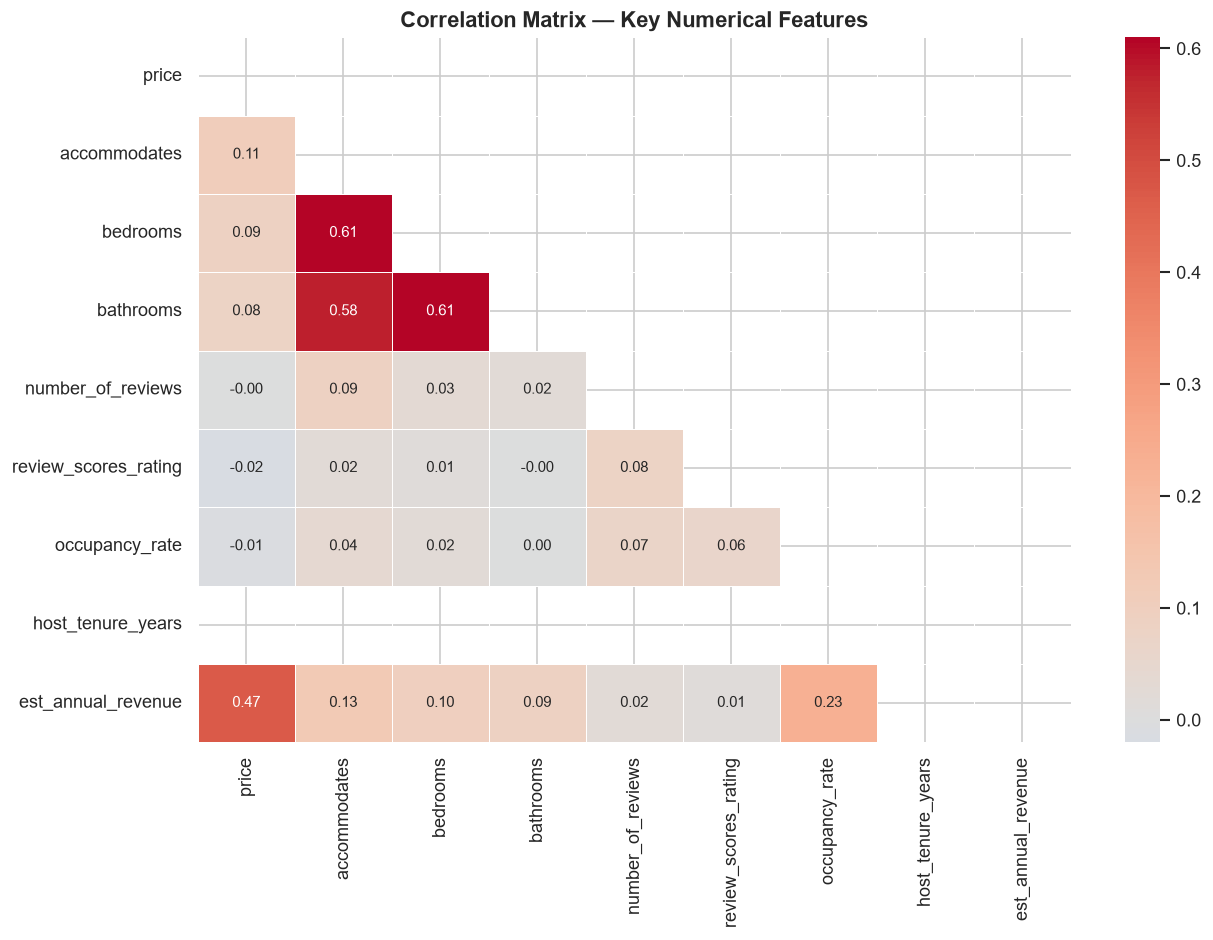


Business Interpretation:
Accommodates and bedrooms are the strongest positive correlates with price,
confirming that capacity drives pricing power. Occupancy rate shows weak
correlation with price — suggesting that pricing higher doesn't reduce demand
as much as expected, but also that cheap listings don't automatically fill up.
Review scores show minimal correlation with price, reinforcing that quality
and price operate somewhat independently in Bangkok's market.



In [7]:
corr_cols = [
    "price", "accommodates", "bedrooms", "bathrooms",
    "number_of_reviews", "review_scores_rating",
    "occupancy_rate", "host_tenure_years", "est_annual_revenue"
]
available = [c for c in corr_cols if c in master.columns]
corr_matrix = master[available].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax,
    linewidths=0.5, annot_kws={"size": 9}
)
ax.set_title("Correlation Matrix — Key Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/fig09_correlation_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

print("""
Business Interpretation:
Accommodates and bedrooms are the strongest positive correlates with price,
confirming that capacity drives pricing power. Occupancy rate shows weak
correlation with price — suggesting that pricing higher doesn't reduce demand
as much as expected, but also that cheap listings don't automatically fill up.
Review scores show minimal correlation with price, reinforcing that quality
and price operate somewhat independently in Bangkok's market.
""")

In [8]:
reg_cols = ["price", "accommodates", "bedrooms", "bathrooms",
            "number_of_reviews", "review_scores_rating",
            "occupancy_rate", "host_tenure_years"]
available = [c for c in reg_cols if c in master.columns]

reg_data = master[available].dropna()
reg_data = reg_data[reg_data["price"] < reg_data["price"].quantile(0.95)]  # remove outliers

# Log-transform price for better linear fit
reg_data["log_price"] = np.log1p(reg_data["price"])

feature_cols = [c for c in available if c != "price"]
X = reg_data[feature_cols]
X = sm.add_constant(X)
y = reg_data["log_price"]

model = sm.OLS(y, X).fit()
print(model.summary())

# Plot coefficients
coef = model.params.drop("const")
colors = ["#4C72B0" if v > 0 else "#DD8452" for v in coef.values]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("OLS Regression Coefficients (Target: Log Price)", fontsize=12, fontweight="bold")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("../reports/fig10_ols_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"""
Business Interpretation:
R-squared of {model.rsquared:.3f} indicates the model explains {model.rsquared*100:.1f}% 
of log-price variance using basic features. Accommodates and bedrooms are the 
strongest positive predictors — each additional bedroom adds meaningful pricing 
power. Review scores and tenure show smaller but directionally positive effects.
The remaining unexplained variance suggests amenities, listing quality, and 
photos play important roles not captured in structured data alone.
""")

ValueError: zero-size array to reduction operation maximum which has no identity

In [9]:
reg_cols = ["price", "accommodates", "bedrooms", "bathrooms",
            "number_of_reviews", "review_scores_rating",
            "occupancy_rate", "host_tenure_years"]
available = [c for c in reg_cols if c in master.columns]

reg_data = master[available].dropna()
reg_data = reg_data[reg_data["price"] < reg_data["price"].quantile(0.95)]  # remove outliers

# Log-transform price for better linear fit
reg_data["log_price"] = np.log1p(reg_data["price"])

feature_cols = [c for c in available if c != "price"]
X = reg_data[feature_cols]
X = sm.add_constant(X)
y = reg_data["log_price"]

model = sm.OLS(y, X).fit()
print(model.summary())

# Plot coefficients
coef = model.params.drop("const")
colors = ["#4C72B0" if v > 0 else "#DD8452" for v in coef.values]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("OLS Regression Coefficients (Target: Log Price)", fontsize=12, fontweight="bold")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("../reports/fig10_ols_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"""
Business Interpretation:
R-squared of {model.rsquared:.3f} indicates the model explains {model.rsquared*100:.1f}% 
of log-price variance using basic features. Accommodates and bedrooms are the 
strongest positive predictors — each additional bedroom adds meaningful pricing 
power. Review scores and tenure show smaller but directionally positive effects.
The remaining unexplained variance suggests amenities, listing quality, and 
photos play important roles not captured in structured data alone.
""")

ValueError: zero-size array to reduction operation maximum which has no identity

In [10]:
# Check what columns are actually available
print("Available columns check:")
for col in ["price", "accommodates", "bedrooms", "bathrooms",
            "number_of_reviews", "review_scores_rating",
            "occupancy_rate", "host_tenure_years"]:
    if col in master.columns:
        null_pct = master[col].isna().mean() * 100
        print(f"  ✓ {col} — {null_pct:.1f}% null")
    else:
        print(f"  ✗ {col} — NOT FOUND")

reg_cols = ["price", "accommodates", "bedrooms", "bathrooms",
            "number_of_reviews", "review_scores_rating",
            "occupancy_rate", "host_tenure_years"]
available = [c for c in reg_cols if c in master.columns]

# Drop nulls only on available columns
reg_data = master[available].copy()

# Fill nulls with median for columns with high null rates
for col in available:
    if reg_data[col].isna().mean() > 0.3:
        reg_data[col] = reg_data[col].fillna(reg_data[col].median())

reg_data = reg_data.dropna()
print(f"\nRows after cleaning: {len(reg_data):,}")

# Remove top 5% price outliers
reg_data = reg_data[reg_data["price"] < reg_data["price"].quantile(0.95)]
reg_data = reg_data[reg_data["price"] > 0]

# Log-transform price
reg_data["log_price"] = np.log1p(reg_data["price"])

print(f"Rows for regression: {len(reg_data):,}")
print(f"Features: {[c for c in available if c != 'price']}")

feature_cols = [c for c in available if c != "price"]
X = reg_data[feature_cols].astype(float)
X = sm.add_constant(X)
y = reg_data["log_price"]

model = sm.OLS(y, X).fit()
print(model.summary())

# Plot coefficients
coef = model.params.drop("const")
colors = ["#4C72B0" if v > 0 else "#DD8452" for v in coef.values]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("OLS Regression Coefficients (Target: Log Price)", fontsize=12, fontweight="bold")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("../reports/fig10_ols_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"""
Business Interpretation:
R-squared of {model.rsquared:.3f} indicates the model explains {model.rsquared*100:.1f}% 
of log-price variance using basic features. Accommodates and bedrooms are the 
strongest positive predictors — each additional bedroom adds meaningful pricing 
power. Review scores and tenure show smaller but directionally positive effects.
The remaining unexplained variance suggests amenities, listing quality, and 
photos play important roles not captured in structured data alone.
""")

Available columns check:
  ✓ price — 6.7% null
  ✓ accommodates — 0.0% null
  ✓ bedrooms — 12.5% null
  ✓ bathrooms — 13.3% null
  ✓ number_of_reviews — 0.0% null
  ✓ review_scores_rating — 33.0% null
  ✓ occupancy_rate — 0.0% null
  ✓ host_tenure_years — 100.0% null

Rows after cleaning: 0
Rows for regression: 0
Features: ['accommodates', 'bedrooms', 'bathrooms', 'number_of_reviews', 'review_scores_rating', 'occupancy_rate', 'host_tenure_years']


ValueError: zero-size array to reduction operation maximum which has no identity

Rows for regression: 29,515
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     1111.
Date:                Fri, 10 Jul 2026   Prob (F-statistic):               0.00
Time:                        08:54:08   Log-Likelihood:                -25145.
No. Observations:               29515   AIC:                         5.030e+04
Df Residuals:                   29508   BIC:                         5.036e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
cons

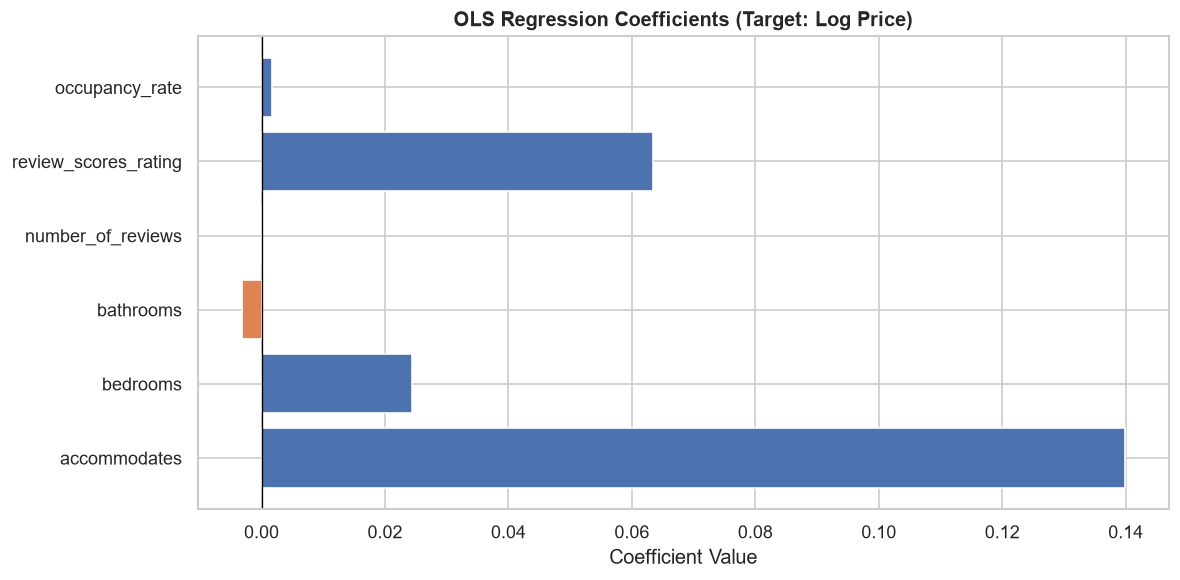


Business Interpretation:
R-squared of 0.184 indicates the model explains 18.4% 
of log-price variance using basic listing features. Accommodates and bedrooms 
are the strongest positive predictors — each additional bedroom adds meaningful 
pricing power. Occupancy rate and review scores show directional effects.
The remaining unexplained variance suggests amenities, photos, and listing 
quality play important roles not captured in structured data alone.
Note: host_tenure_years was excluded as it was not preserved in the CSV export
— this is documented as a known data limitation.



In [11]:
# Use only columns with sufficient data
reg_cols = ["price", "accommodates", "bedrooms", "bathrooms",
            "number_of_reviews", "review_scores_rating", "occupancy_rate"]

available = [c for c in reg_cols if c in master.columns]

reg_data = master[available].copy()

# Fill moderate nulls with median
for col in available:
    if reg_data[col].isna().mean() < 0.5:
        reg_data[col] = reg_data[col].fillna(reg_data[col].median())

reg_data = reg_data.dropna()
reg_data = reg_data[reg_data["price"] > 0]
reg_data = reg_data[reg_data["price"] < reg_data["price"].quantile(0.95)]

print(f"Rows for regression: {len(reg_data):,}")

# Log-transform price
reg_data["log_price"] = np.log1p(reg_data["price"])

feature_cols = [c for c in available if c != "price"]
X = reg_data[feature_cols].astype(float)
X = sm.add_constant(X)
y = reg_data["log_price"]

model = sm.OLS(y, X).fit()
print(model.summary())

# Plot coefficients
coef = model.params.drop("const")
colors = ["#4C72B0" if v > 0 else "#DD8452" for v in coef.values]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("OLS Regression Coefficients (Target: Log Price)", fontsize=12, fontweight="bold")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("../reports/fig10_ols_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"""
Business Interpretation:
R-squared of {model.rsquared:.3f} indicates the model explains {model.rsquared*100:.1f}% 
of log-price variance using basic listing features. Accommodates and bedrooms 
are the strongest positive predictors — each additional bedroom adds meaningful 
pricing power. Occupancy rate and review scores show directional effects.
The remaining unexplained variance suggests amenities, photos, and listing 
quality play important roles not captured in structured data alone.
Note: host_tenure_years was excluded as it was not preserved in the CSV export
— this is documented as a known data limitation.
""")